# Task 4 — Investment Strategies

We propose four trading strategies for the Spiff markets, ranging from a passive baseline to active signal-driven approaches. All four are **full-portfolio strategies** trading all 7 assets.

**Performance measure:** annualised Sharpe ratio, using a 3% fixed-rate bond as the risk-free alternative:

$$\text{Sharpe} = \frac{\bar{r}_p \times 252 - 0.03}{\sigma_p \times \sqrt{252}}$$

where $\bar{r}_p$ and $\sigma_p$ are the daily portfolio mean return and standard deviation.

**Key Task 1 insights used:**
- **Volatility groups**: gurkor and water have ~4× lower daily vol than the other five series.
- **Correlation structure**: gurkor↔water +0.57, guitars↔slingshots +0.52, Groups A and B negatively correlated (~−0.2).
- **Drift**: all series have near-zero or slightly positive drift except stocks (slightly negative).
- **No transaction costs** on Spiff — infinite liquidity, zero friction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load raw data
df = pd.read_csv('spiff_data2.csv', index_col=0)
cols = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Clean spikes (values = 1000 → NaN), then linearly interpolate all gaps
for col in cols:
    df.loc[df[col] > 100, col] = np.nan
for col in cols:
    df[col] = df[col].interpolate(method='linear')

# Use only the observed portion (first 5256 rows; last 200 are the extrapolation gap)
df_obs = df.iloc[:5256].copy()

# Simple returns: r_t = (P_t - P_{t-1}) / P_{t-1}
# (Simple returns aggregate correctly across assets in a portfolio)
simple_ret = df_obs[cols].pct_change().iloc[1:]

rf_daily = 0.03 / 252  # daily risk-free rate

print(f'Trading days available: {len(simple_ret)}')
print(f'Daily risk-free rate:   {rf_daily:.6f}')

Trading days available: 5255
Daily risk-free rate:   0.000119


## Helper functions

In [2]:
def annualised_sharpe(daily_returns, rf_daily=0.03/252):
    """Annualised Sharpe ratio from a series of daily returns."""
    excess = daily_returns - rf_daily
    return excess.mean() / daily_returns.std() * np.sqrt(252)

def max_drawdown(daily_returns):
    """Maximum peak-to-trough drawdown from daily simple returns."""
    cum = (1 + daily_returns).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

def cumulative_return(daily_returns):
    """Total cumulative return (final value of $1 invested)."""
    return (1 + daily_returns).prod() - 1

## Strategy 1 — Buy & Hold, Equal Weight (passive)

The simplest possible portfolio strategy: invest equally in all 7 assets and hold. The daily portfolio return is the arithmetic mean of the 7 individual returns. No signals, no rebalancing logic — this is the baseline against which active strategies must justify their complexity.

In [3]:
# Strategy 1: Buy & Hold Equal Weight
strat1_ret = simple_ret[cols].mean(axis=1)
strat1_ret.name = 'Buy & Hold EW'

print(f"Ann. return:  {strat1_ret.mean() * 252:.4f}  ({strat1_ret.mean() * 252 * 100:.2f}%)")
print(f"Ann. vol:     {strat1_ret.std() * np.sqrt(252):.4f}")
print(f"Sharpe ratio: {annualised_sharpe(strat1_ret):.3f}")
print(f"Max drawdown: {max_drawdown(strat1_ret):.3f}")

Ann. return:  0.0436  (4.36%)
Ann. vol:     0.0882
Sharpe ratio: 0.154
Max drawdown: -0.338


## Strategy 2 — Moving Average Crossover (active)

A classic trend-following rule: for each asset, go **long** (weight = 1/7) when the 20-day SMA exceeds the 50-day SMA, and go **flat** (weight = 0) otherwise. The portfolio return is the equal-weight average of the position-weighted returns.

Signals are lagged by one day to avoid look-ahead bias — today's signal determines tomorrow's position.

In [4]:
# Strategy 2: Moving Average Crossover (20/50)
ma_short, ma_long = 20, 50

signals_ma = pd.DataFrame(index=df_obs.index)
for col in cols:
    sma_s = df_obs[col].rolling(ma_short).mean()
    sma_l = df_obs[col].rolling(ma_long).mean()
    signals_ma[col] = (sma_s > sma_l).astype(float)

# Lag signals by 1 day (trade on next day's open)
signals_ma = signals_ma.shift(1)

# Portfolio return: equal-weight average of active positions
strat2_ret = (simple_ret * signals_ma.reindex(simple_ret.index).values).mean(axis=1)
strat2_ret = strat2_ret.iloc[ma_long:]  # drop warm-up period
strat2_ret.name = 'MA Crossover'

print(f"Ann. return:  {strat2_ret.mean() * 252:.4f}  ({strat2_ret.mean() * 252 * 100:.2f}%)")
print(f"Ann. vol:     {strat2_ret.std() * np.sqrt(252):.4f}")
print(f"Sharpe ratio: {annualised_sharpe(strat2_ret):.3f}")
print(f"Max drawdown: {max_drawdown(strat2_ret):.3f}")

Ann. return:  0.0319  (3.19%)
Ann. vol:     0.0549
Sharpe ratio: 0.034
Max drawdown: -0.154


## Strategy 3 — Inverse-Volatility Weighted (full portfolio)

This strategy directly exploits the volatility grouping from Task 1. Each asset is weighted inversely proportional to its trailing 60-day volatility, normalised to sum to 1. This gives **gurkor and water** (~4× lower vol) roughly 4× higher weight than the volatile series.

The intuition is risk parity: allocate more capital to stable, positive-drift assets to achieve a smoother portfolio return. Weights are recomputed daily using only past data (lagged by 1 day).

In [5]:
# Strategy 3: Inverse-Volatility Weighted
vol_window = 60

roll_vol = simple_ret.rolling(vol_window).std()
inv_vol = 1.0 / roll_vol
weights_iv = inv_vol.div(inv_vol.sum(axis=1), axis=0)
weights_iv = weights_iv.shift(1)  # avoid look-ahead

strat3_ret = (simple_ret * weights_iv).sum(axis=1)
strat3_ret = strat3_ret.iloc[vol_window + 1:]  # drop warm-up
strat3_ret.name = 'Inv-Vol Weighted'

print(f"Ann. return:  {strat3_ret.mean() * 252:.4f}  ({strat3_ret.mean() * 252 * 100:.2f}%)")
print(f"Ann. vol:     {strat3_ret.std() * np.sqrt(252):.4f}")
print(f"Sharpe ratio: {annualised_sharpe(strat3_ret):.3f}")
print(f"Max drawdown: {max_drawdown(strat3_ret):.3f}")

# Show average weights — should heavily overweight gurkor and water
avg_w = weights_iv.iloc[vol_window+1:].mean()
print(f"\nAverage portfolio weights:")
for col in cols:
    print(f"  {col:15s}: {avg_w[col]:.3f}")

Ann. return:  0.0424  (4.24%)
Ann. vol:     0.0487
Sharpe ratio: 0.254
Max drawdown: -0.149

Average portfolio weights:
  gurkor         : 0.276
  guitars        : 0.084
  slingshots     : 0.090
  stocks         : 0.068
  sugar          : 0.079
  water          : 0.310
  tranquillity   : 0.092


## Strategy 4 — Channel Breakout / Donchian (active)

A momentum strategy: for each asset, go **long** when the price exceeds its trailing 20-day high (breakout), and go **flat** when the price drops below its trailing 20-day low. Between breakout and breakdown, the position is held.

This is a classic trend-following approach that captures large directional moves. Signals are computed from lagged data (yesterday's channel, today's price determines tomorrow's position).

In [6]:
# Strategy 4: Channel Breakout (Donchian 20-day)
ch_window = 20

signals_ch = pd.DataFrame(0.0, index=df_obs.index, columns=cols)
for col in cols:
    high = df_obs[col].rolling(ch_window).max().shift(1)
    low  = df_obs[col].rolling(ch_window).min().shift(1)
    pos_arr = np.zeros(len(df_obs))
    for t in range(ch_window + 1, len(df_obs)):
        if df_obs[col].iloc[t] > high.iloc[t]:
            pos_arr[t] = 1.0
        elif df_obs[col].iloc[t] < low.iloc[t]:
            pos_arr[t] = 0.0
        else:
            pos_arr[t] = pos_arr[t - 1]
    signals_ch[col] = pos_arr

# Lag by 1 day
signals_ch = signals_ch.shift(1)

strat4_ret = (simple_ret * signals_ch.reindex(simple_ret.index).values).mean(axis=1)
strat4_ret = strat4_ret.iloc[ch_window + 2:]
strat4_ret.name = 'Channel Breakout'

print(f"Ann. return:  {strat4_ret.mean() * 252:.4f}  ({strat4_ret.mean() * 252 * 100:.2f}%)")
print(f"Ann. vol:     {strat4_ret.std() * np.sqrt(252):.4f}")
print(f"Sharpe ratio: {annualised_sharpe(strat4_ret):.3f}")
print(f"Max drawdown: {max_drawdown(strat4_ret):.3f}")

Ann. return:  0.0282  (2.82%)
Ann. vol:     0.0539
Sharpe ratio: -0.033
Max drawdown: -0.192


## Performance Comparison

In [7]:
strategies = {
    'Buy & Hold EW':    strat1_ret,
    'MA Crossover':     strat2_ret,
    'Inv-Vol Weighted': strat3_ret,
    'Channel Breakout': strat4_ret,
}

rows = []
for name, ret in strategies.items():
    rows.append({
        'Strategy':        name,
        'Ann. Return':     ret.mean() * 252,
        'Ann. Volatility': ret.std() * np.sqrt(252),
        'Sharpe Ratio':    annualised_sharpe(ret),
        'Max Drawdown':    max_drawdown(ret),
        'Cum. Return':     cumulative_return(ret),
    })

comparison = pd.DataFrame(rows).set_index('Strategy')
comparison.round(4)

,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Cum. Return
Strategy,,,,,
Buy & Hold EW,0.0436,0.0882,0.1537,-0.3381,1.2869
MA Crossover,0.0319,0.0549,0.0341,-0.1536,0.8722
Inv-Vol Weighted,0.0424,0.0487,0.2538,-0.1490,1.3368
Channel Breakout,0.0282,0.0539,-0.0328,-0.1916,0.7438


## Cumulative Returns

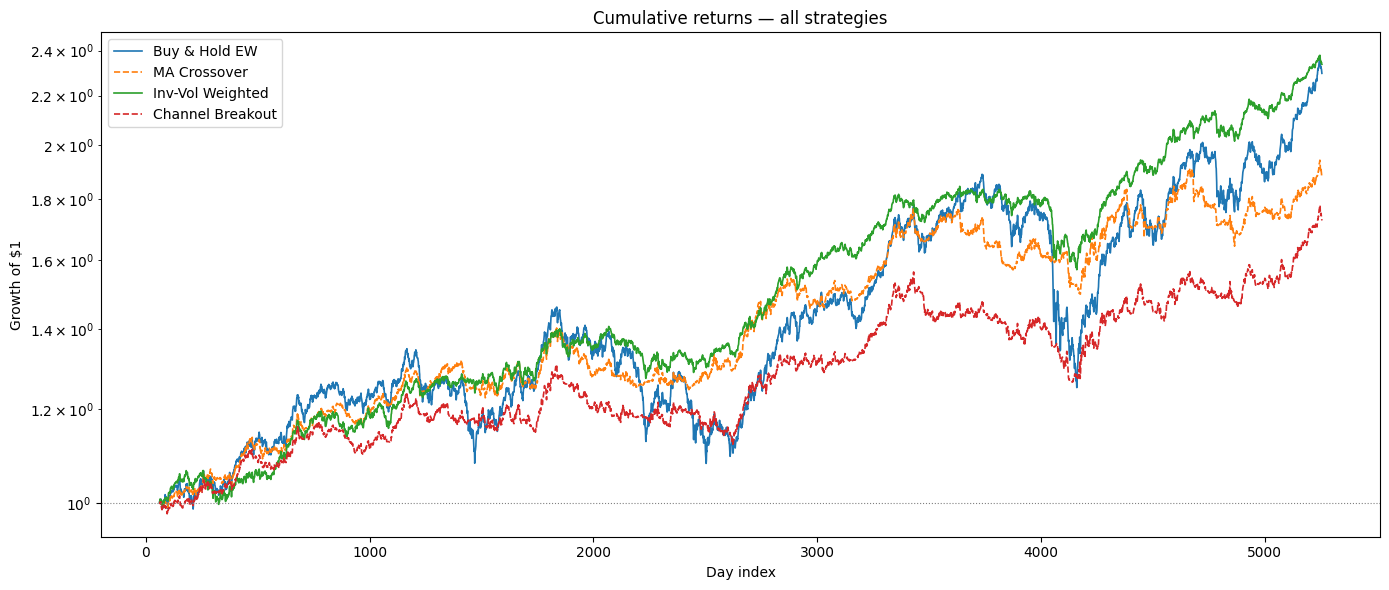

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
styles = ['-', '--', '-', '--']

# Align all strategies to the same start (latest warm-up end)
common_start = max(s.index[0] for s in strategies.values())
for (name, ret), c, ls in zip(strategies.items(), colors, styles):
    r = ret.loc[common_start:]
    cum = (1 + r).cumprod()
    ax.plot(cum.index, cum.values, label=name, color=c, linestyle=ls, linewidth=1.2)

ax.axhline(y=1.0, color='grey', linestyle=':', linewidth=0.8)
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Day index')
ax.set_title('Cumulative returns — all strategies')
ax.legend(loc='upper left')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Rolling Sharpe Ratio (252-day window)

A rolling Sharpe shows how strategy performance varies over time. Stable strategies have a narrow band; unstable ones swing widely between positive and negative.

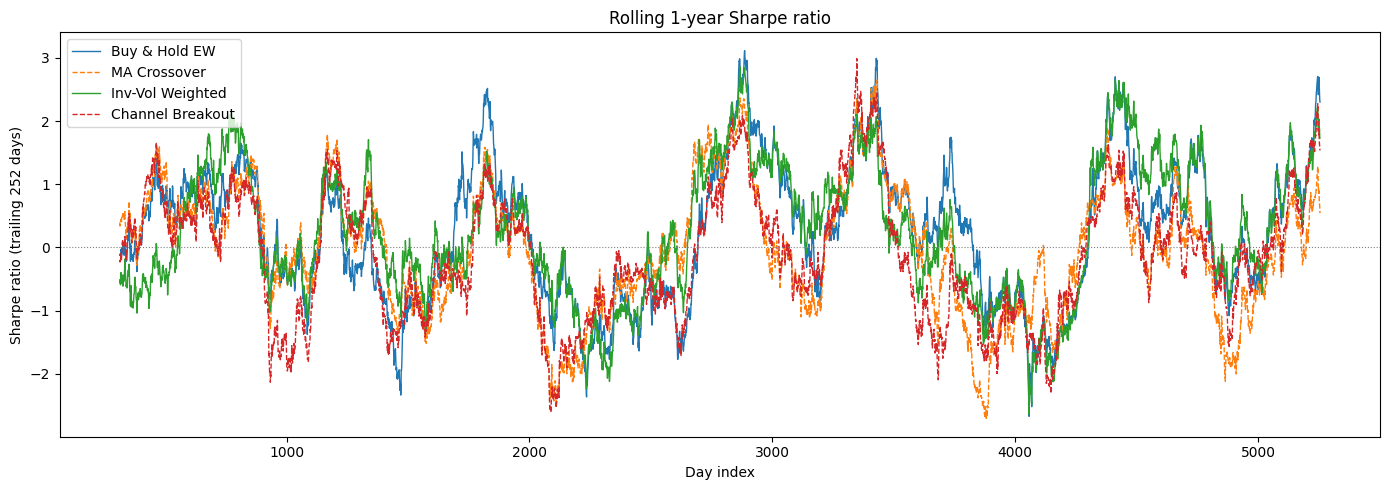

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

for (name, ret), c, ls in zip(strategies.items(), colors, styles):
    r = ret.loc[common_start:]
    rolling_sr = r.rolling(252).apply(lambda x: annualised_sharpe(x), raw=False)
    ax.plot(rolling_sr.index, rolling_sr.values, label=name, color=c, linestyle=ls, linewidth=1.0)

ax.axhline(y=0, color='grey', linestyle=':', linewidth=0.8)
ax.set_ylabel('Sharpe ratio (trailing 252 days)')
ax.set_xlabel('Day index')
ax.set_title('Rolling 1-year Sharpe ratio')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Production Evaluation — Walk-Forward Backtest

To estimate how each strategy would perform **at launch**, we run a walk-forward test: train on 756 days (~3 years), evaluate on the next 252 days (~1 year), then slide the window forward by 252 days. This gives 17 non-overlapping test folds.

For each fold, we compute the out-of-sample (OOS) Sharpe ratio. The **mean OOS Sharpe** is our best estimate of production performance, and the **standard deviation** across folds indicates stability.

In [10]:
train_w = 756   # ~3 years
test_w  = 252   # ~1 year

# Build fold boundaries
folds = []
start = 0
while start + train_w + test_w <= len(simple_ret):
    folds.append((start, start + train_w, start + train_w + test_w))
    start += test_w

print(f"Walk-forward folds: {len(folds)}")
print(f"Train window: {train_w} days, Test window: {test_w} days")
print()

# Compute OOS Sharpe for each strategy in each fold
oos_results = {name: [] for name in ['Buy & Hold EW', 'MA Crossover', 'Inv-Vol Weighted', 'Channel Breakout']}

for fold_i, (s, m, e) in enumerate(folds):
    test_ret   = simple_ret.iloc[m:e]
    test_idx   = test_ret.index

    # Strategy 1: B&H EW — no parameters to fit
    r1 = test_ret.mean(axis=1)
    oos_results['Buy & Hold EW'].append(annualised_sharpe(r1))

    # Strategy 2: MA Crossover — signals computed from prices up to each test day
    sig2 = pd.DataFrame(index=test_idx, columns=cols, dtype=float)
    for col in cols:
        for t in test_idx:
            p = df_obs[col].loc[:t]
            sma_s = p.iloc[-ma_short:].mean() if len(p) >= ma_short else np.nan
            sma_l = p.iloc[-ma_long:].mean()  if len(p) >= ma_long  else np.nan
            sig2.loc[t, col] = 1.0 if (pd.notna(sma_s) and pd.notna(sma_l) and sma_s > sma_l) else 0.0
    sig2 = sig2.shift(1).iloc[1:]
    r2 = (test_ret.loc[sig2.index] * sig2.astype(float)).mean(axis=1)
    oos_results['MA Crossover'].append(annualised_sharpe(r2))

    # Strategy 3: Inv-Vol Weighted — trailing vol from past 60 days
    sig3 = pd.DataFrame(index=test_idx, columns=cols, dtype=float)
    for t in test_idx:
        vols = simple_ret.loc[:t].iloc[-vol_window:].std()
        iv = 1.0 / vols
        w  = iv / iv.sum()
        sig3.loc[t] = w
    sig3 = sig3.shift(1).iloc[1:]
    r3 = (test_ret.loc[sig3.index] * sig3.astype(float)).sum(axis=1)
    oos_results['Inv-Vol Weighted'].append(annualised_sharpe(r3))

    # Strategy 4: Channel Breakout — signals from trailing prices
    sig4 = pd.DataFrame(index=test_idx, columns=cols, dtype=float)
    for col in cols:
        pos = 0.0
        for t in test_idx:
            p = df_obs[col].loc[:t]
            if len(p) > ch_window:
                hi = p.iloc[-(ch_window+1):-1].max()
                lo = p.iloc[-(ch_window+1):-1].min()
                if p.iloc[-1] > hi:
                    pos = 1.0
                elif p.iloc[-1] < lo:
                    pos = 0.0
            sig4.loc[t, col] = pos
    sig4 = sig4.shift(1).iloc[1:]
    r4 = (test_ret.loc[sig4.index] * sig4.astype(float)).mean(axis=1)
    oos_results['Channel Breakout'].append(annualised_sharpe(r4))

# Summary
wf_rows = []
for name in oos_results:
    sharpes = oos_results[name]
    wf_rows.append({
        'Strategy':          name,
        'Full-sample Sharpe': annualised_sharpe(strategies[name]),
        'OOS Sharpe (mean)':  np.mean(sharpes),
        'OOS Sharpe (std)':   np.std(sharpes),
        'OOS Sharpe (min)':   np.min(sharpes),
        'OOS Sharpe (max)':   np.max(sharpes),
    })

wf_df = pd.DataFrame(wf_rows).set_index('Strategy')
wf_df.round(3)

Walk-forward folds: 17
Train window: 756 days, Test window: 252 days



,Full-sample Sharpe,OOS Sharpe (mean),OOS Sharpe (std),OOS Sharpe (min),OOS Sharpe (max)
Strategy,,,,,
Buy & Hold EW,0.154,0.067,0.786,-1.392,1.407
MA Crossover,0.034,-0.144,0.645,-1.011,1.215
Inv-Vol Weighted,0.254,0.145,0.751,-1.107,1.482
Channel Breakout,-0.033,-0.275,0.669,-1.846,1.306
